*Importing the needed libraries:*

In [ ]:
import os
import math
import sys
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from typing import List, Tuple, Dict, Optional
from dataclasses import dataclass
from tqdm.notebook import tqdm

from sksurv.util import Surv
from sksurv.metrics import concordance_index_censored
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sklearn.model_selection import StratifiedKFold, KFold
from sklearn.impute import SimpleImputer

from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.plotting import add_at_risk_counts
from statsmodels.stats.multitest import multipletests
from lifelines.statistics import logrank_test, multivariate_logrank_test

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.table import Table
import matplotlib.transforms as mtransforms

import scipy.stats
from scipy.stats import norm, zscore, fisher_exact, chi2_contingency, mannwhitneyu

*Setting the parameters for AI-friendly export format of the plots:*

In [ ]:
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   # embed TrueType fonts, keep text editable
mpl.rcParams['ps.fonttype'] = 42
mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['DejaVu Sans'] 

*Building the HR plots for each figure:*

In [17]:
CD27_renamer_dict = {
    "CD4 TEM CD27hi CD29+":"CD4 TEM CD27dim CD29+",
    "CD4 TEM CD27hi CD29+ CD57+":"CD4 TEM CD27dim CD29+ CD57+",
    "CD4 TEM CD27hi CD29+ CD57+ GPR56+":"CD4 TEM CD27dim CD29+ CD57+ GPR56+",
    "CD4 TEM CD27lo CD29+":"CD4 TEM CD27- CD29+",
    "CD4 TEM CD27lo CD29+ GPR56+":"CD4 TEM CD27- CD29+ GPR56+",
    "CD8 CCR7- CD45RA+ CD27+ CD57+ GPR56+":"CD8 TEMRA CD27dim CD57+ GPR56+",
    "CD8 CCR7- CD45RA+ CD27+ GPR56+":"CD8 TEMRA CD27dim GPR56+",
    "CD8 CCR7- CD45RAmid CD27+ CD57+":"CD8 TEM-adv1 CD27dim CD57+",
    "CD8 CCR7- CD45RAmid CD27+ CD57+ GPR56+":"CD8 TEM-adv1 CD27dim CD57+ GPR56+",
    "CD8 CCR7- CD45RAmid CD27+ GPR56+":"CD8 TEM-adv1 CD27dim GPR56+",
    "CD8dim TEM GPR56+":"CD8dim TEM-adv0 CD27dim GPR56+",
}

In [18]:
def filtering_table(input_df, pval_threshold = .05):
    input_df = input_df[input_df['MATCHING_DIRECTION'] == 'MATCH']
    input_df = input_df[input_df['max_pvalue_in_2cohorts'] < pval_threshold]

    for element in CD27_renamer_dict:
        input_df['Marker'] = input_df['Marker'].str.replace(element,CD27_renamer_dict[element])
    return input_df

def HR_calculator(input_df):
    input_df['HR_OC'] = np.exp(input_df['beta_coef_OC'])
    input_df['HR_VC'] = np.exp(input_df['beta_coef_VC'])

    input_df['beta_coef_OC_lower'] = input_df['beta_coef_OC'] - 1.96*input_df['SE_OC']
    input_df['HR_OC_lower'] = np.exp(input_df['beta_coef_OC_lower'])
    input_df['beta_coef_OC_upper'] = input_df['beta_coef_OC'] + 1.96*input_df['SE_OC']
    input_df['HR_OC_upper'] = np.exp(input_df['beta_coef_OC_upper'])
    input_df['beta_coef_VC_lower'] = input_df['beta_coef_VC'] - 1.96*input_df['SE_VC']
    input_df['HR_VC_lower'] = np.exp(input_df['beta_coef_VC_lower'])
    input_df['beta_coef_VC_upper'] = input_df['beta_coef_VC'] + 1.96*input_df['SE_VC']
    input_df['HR_VC_upper'] = np.exp(input_df['beta_coef_VC_upper'])

    for element in CD27_renamer_dict:
        input_df['Marker'] = input_df['Marker'].str.replace(element,CD27_renamer_dict[element])
    return input_df

<br></br>
*Figure 2: HR plots for relapse-related CD8 parameters:*

In [20]:
def HR_plotter(to_visualize, df, fig_width, fig_height, bbox_legend_pos, xlimits_default, xlimits, plot_title, highlight_bold = False, num_highlightbold = None, save_fig = False, save_path = None):
    to_visualize = 'HR'
    n = len(df)
    y = np.arange(n)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height*n), constrained_layout=False)
    offset = 0.15
    if to_visualize == 'beta': 
        # --- Cohort 1 (blue) ---
        oc = ax.errorbar(
            df["beta_coef_OC"], y - offset,
            xerr=[df["beta_coef_OC"] - df["beta_coef_OC_lower"], df["beta_coef_OC_upper"] - df["beta_coef_OC"]],
            fmt="s", markersize=6,
            color="#1f77b4", ecolor="#1f77b4",
            capsize=3,
            label=f"Cohort 1 ({list(df['total_patients_OC'].unique())[0]} pat.)"         # <--- label here
        )

        # --- Cohort 2 (red) ---
        vc = ax.errorbar(
            df["beta_coef_VC"], y + offset,
            xerr=[df["beta_coef_VC"] - df["beta_coef_VC_lower"], df["beta_coef_VC_upper"] - df["beta_coef_VC"]],
            fmt="s", markersize=6,
            color="#d62727", ecolor="#d62727",
            capsize=3,
            label=f"Cohort 2 ({list(df['total_patients_VC'].unique())[0]} pat.)"         # <--- and here
        )
        ax.axvline(0, color="gray", linestyle="--", linewidth=1)  # no label

    elif to_visualize == 'HR':
        # --- Cohort 1 (blue) ---
        oc = ax.errorbar(
            df["HR_OC"], y - offset,
            xerr=[df["HR_OC"] - df["HR_OC_lower"], df["HR_OC_upper"] - df["HR_OC"]],
            fmt="s", markersize=6,
            color="#1f77b4", ecolor="#1f77b4",
            capsize=3,
            label=f"Cohort 1 ({list(df['total_patients_OC'].unique())[0]} pat.)"         # <--- label here
        )

        # --- Cohort 2 (red) ---
        vc = ax.errorbar(
            df["HR_VC"], y + offset,
            xerr=[df["HR_VC"] - df["HR_VC_lower"], df["HR_VC_upper"] - df["HR_VC"]],
            fmt="s", markersize=6,
            color="#d62727", ecolor="#d62727",
            capsize=3,
            label=f"Cohort 2 ({list(df['total_patients_VC'].unique())[0]} pat.)"         # <--- and here
        )
        ax.axvline(1, color="gray", linestyle="--", linewidth=1)  # no label

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_yticks(y)
    ax.set_yticklabels(df["Marker"], fontsize = 10)
    ax.set_ylim(-0.5, n - 0.5)
    if xlimits_default == False:
        ax.set_xlim(xlimits[0],xlimits[1])
    ax.invert_yaxis()

    if highlight_bold:
        yticklabels = ax.get_yticklabels()

        for label in yticklabels:
            text = label.get_text()

            if text in num_highlightbold:
                label.set_fontweight('bold')
                # optional:
                # label.set_color('black')
            else:
                label.set_color('gray')

    legend = ax.legend(bbox_to_anchor=bbox_legend_pos, framealpha = 0,
            loc='upper center', 
            title = '', ncol=2, columnspacing=1.5, handletextpad=0.2, fontsize = 10)                  # <--- no args, uses the labels above
    if to_visualize == 'beta': 
        ax.set_xlabel("log(HR) (95% CI)", fontsize = 10)
    elif to_visualize == 'HR': 
        ax.set_xlabel("HR (95% CI)", fontsize = 10)
    ax.set_title(plot_title, pad=25, fontsize = 10)

    plt.tight_layout()
    if save_fig:
        plt.savefig(save_path, bbox_inches = 'tight')
    plt.show()

In [ ]:
submit_info_dict = {
    '2000days_CompRisk_aGVHD1234_cGVHD12_Relapse_MainRisk_Relapse_main': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            'High Resolution CD8 TEM-adv1 CD27dim CD57+ GPR56+ of CD45pos': 'HighRes CD8 TEM-adv1\nCD27dim CD57+ GPR56+\nof CD45pos',
            'CD8 CCR7- CD45RAmid of CD8 TEM': 'CD8 TEM-adv1\nof CD8 TEM',
        },
        'width': 5,
        'per_row_height': 1.2,
        'xlimits_default': False,
        'xlimits': [0,2],
        'bbox_legend_pos': (0.5,1.3),
        'plot_title': 'Hazard for "Relapse as a first event"\nCompeting risks: aGvHD (1-4), cGvHD (1-2)',
        'highlight_bold': True,
        'num_highlightbold': [
            'HighRes CD8 TEM-adv1\nCD27dim CD57+ GPR56+\nof CD45pos',
        ],
    },

    '2000days_CompRisk_aGVHD1234_cGVHD2_Relapse_MainRisk_Relapse_main': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            'High Resolution CD8 TEM-adv1 CD27dim CD57+ GPR56+ of CD45pos': 'HighRes CD8 TEM-adv1\nCD27dim CD57+ GPR56+\nof CD45pos',
        },
        'width': 3,
        'per_row_height': 0.55,
        'xlimits': [0,2],
        'xlimits_default': False,
        'bbox_legend_pos': (0.5,1.8),
        'plot_title': 'Hazard for "Relapse as a first event"\nCompeting risks: aGvHD (1-4), cGvHD (2)',
        'highlight_bold': False,
        'num_highlightbold': []
    },

    '2000days_CompRisk_aGVHD1234_cGVHD2_Relapse_MainRisk_Relapse_extended': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            # 'High Resolution CD8 Naive CD27+ of CD45pos':
            #     r'CD8 T$_{\mathrm{NV}}$',
            #     # '\n'
            #     # r'of CD45pos',
            # 'CD8 CCR7- CD45RA- of CD45pos':
            #     r'CD8 T$_{\mathrm{EM\!-\!adv0}}$',
            #     # '\n'
            #     # r'of CD45pos',
            # 'CD8 CCR7- CD45RAmid of CD45pos':
            #     r'CD8 T$_{\mathrm{EM\!-\!adv1}}$',
            #     # '\n'
            #     # r'of CD45pos',

            # 'High Resolution CD8 CCR7- CD45RAmid CD27+ CD57+ GPR56+ of CD45pos':
            #     r'HighRes CD8 T$_{\mathrm{EM\!-\!adv1}}$'
            #     '\n'
            #     r'CD27$^{+}$ CD57$^{+}$ GPR56$^{+}$',
            #     # '\n'
            #     # r'of CD45pos',

            # 'High Resolution CD8 CCR7- CD45RAmid/+ CD57+ GPR56+ of CD45pos':
            #     r'CD8 T$_{\mathrm{EM\!-\!adv2}}$',
            #     # '\n'
            #     # r'of CD45pos',
            # 'CD8 CCR7- CD45RA+ of CD45pos':
            #     r'CD8 T$_{\mathrm{EMRA}}$',
            #     # '\n'
            #     # r'of CD45pos',

            'High Resolution CD8 Naive CD27+ of CD45pos': 'CD8 TNV',
            'CD8 CCR7- CD45RA- of CD45pos': 'CD8 TEM-adv0',
            'CD8 CCR7- CD45RAmid of CD45pos': 'CD8 TEM-adv1',
            'High Resolution CD8 TEM-adv1 CD27dim CD57+ GPR56+ of CD45pos': 'HighRes CD8 TEM-adv1\nCD27dim CD57+ GPR56+',
            'High Resolution CD8 CCR7- CD45RAmid/+ CD57+ GPR56+ of CD45pos': 'CD8 TEM-adv2',
            'CD8 CCR7- CD45RA+ of CD45pos': 'CD8 TEMRA',
        },
        'width': 5,
        'per_row_height': 0.55,
        'xlimits': [0,4],
        'xlimits_default': False,
        'bbox_legend_pos': (0.5,1.15),
        'plot_title': 'Hazard for "Relapse as a first event" (% of CD45+)\nCompeting risks: aGvHD (1-4), cGvHD (2)',
        'highlight_bold': True,
        'num_highlightbold': [
            'HighRes CD8 TEM-adv1\nCD27dim CD57+ GPR56+',
        ]
    },
    
    '2000days_CompRisk_aGVHD34_cGVHD12_Relapse_MainRisk_Relapse_main': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'CD8 TEM-adv1\nCD57+ GPR56+\nof CD8 TEM',
        },
        'width': 3,
        'per_row_height': 0.7,
        'xlimits': [0,2],
        'xlimits_default': False,
        'bbox_legend_pos': (0.5,1.6),
        'plot_title': 'Hazard for "Relapse as a first event"\nCompeting risks: aGvHD (3-4), cGvHD (1-2)',
        'highlight_bold': False,
        'num_highlightbold': []
    },

    '2000days_CompRisk_aGVHD34_cGVHD12_Relapse_MainRisk_Relapse_extended': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            # 'CD8 CCR7- CD45RA- of CD8 TEM': 'CD8 TEM-adv0',
            'High Resolution CD8 TEM CD27+ of CD8 TEM': 'CD8 TEM-adv0\nCD57- GPR56-',
            'High Resolution CD8 TEM CD27+ CD57+ of CD8 TEM': 'CD8 TEM-adv0\nCD57+ GPR56-',
            'High Resolution CD8dim TEM GPR56+ of CD8 TEM': 'CD8 TEM-adv0\nCD57- GPR56+',

            # 'CD8 CCR7- CD45RAmid of CD8 TEM': 'CD8 TEM-adv1',
            'CD8 TEM adv1 GPR56- CD57- of CD8 TEM': 'CD8 TEM-adv1\nCD57- GPR56-',
            'High Resolution CD8 TEM-adv1 CD27+ CD57+ of CD8 TEM': 'CD8 TEM-adv1\nCD57+ GPR56-',

            'CD8 TEM adv1 GPR56+ CD57- of CD8 TEM': 'CD8 TEM-adv1\nCD57- GPR56+',
            'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'CD8 TEM-adv1\nCD57+ GPR56+',
            'High Resolution CD8 CCR7- CD45RAmid/+ CD57+ GPR56+ of CD8 TEM': 'CD8 TEM-adv2\nCD57+ GPR56+',
        },
        'width': 5,
        'per_row_height': 0.65,
        'xlimits': [0,5],
        'xlimits_default': False,
        'bbox_legend_pos': (0.5,1.15),
        'plot_title': 'Hazard for "Relapse as a first event" (% of CD8 TEM)\nCompeting risks: aGvHD (3-4), cGvHD (1-2)',
        'highlight_bold': True,
        'num_highlightbold': [
            'CD8 TEM-adv1\nCD57+ GPR56+',
        ]
    },

    '2000days_CompRisk_aGVHD34_cGVHD2_Relapse_MainRisk_Relapse_main': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            'CD8 TEM adv0/adv1/adv2 GPR56- CD57- of CD8 TEM': 'CD8 TEM-adv0/adv1/adv2\nGPR56- CD57-\nof CD8 TEM',
            'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'CD8 TEM-adv1\nGPR56+ CD57+\nof CD8 TEM',
            'CD8 TEM adv1 GPR56+ CD57+ of CD8': 'CD8 TEM adv1\nGPR56+ CD57+\nof CD8',
        },
        'width': 5,
        'per_row_height': 1,
        'xlimits': [0,7],
        'xlimits_default': False,
        'bbox_legend_pos': (0.5,1.25),
        'plot_title': 'Hazard for "Relapse as a first event"\nCompeting risks: aGvHD (3-4), cGvHD (2)',
        'highlight_bold': True,
        'num_highlightbold': [
            'CD8 TEM-adv1\nGPR56+ CD57+\nof CD8 TEM',
        ]
    },

    '2000days_CompRisk_aGVHD234_cGVHD12_Relapse_MainRisk_Relapse_main': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            'CD8 TEM adv0/adv1/adv2 CD57- of CD8 TEM': 'CD8 TEM adv0/adv1/adv2\nCD57- of CD8 TEM',
            'CD8 TEM adv1 GPR56+ CD57+ of CD8 TEM': 'CD8 TEM adv1\nGPR56+ CD57+\nof CD8 TEM',
            'High Resolution CD8 TEM CD27+ of CD8': 'HighRes CD8 TEM\nCD27+ of CD8',
        },
        'width': 5,
        'per_row_height': 1,
        'xlimits': [0,7],
        'xlimits_default': False,
        'bbox_legend_pos': (0.5,1.2),
        'plot_title': 'Hazard for "Relapse as a first event"\nCompeting risks: aGvHD (2-4), cGvHD (1-2)',
        'highlight_bold': True,
        'num_highlightbold': [
            'CD8 TEM adv1\nGPR56+ CD57+\nof CD8 TEM',
        ]
    },
}

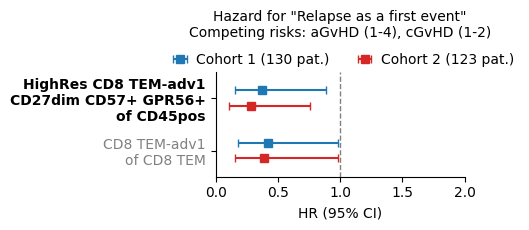

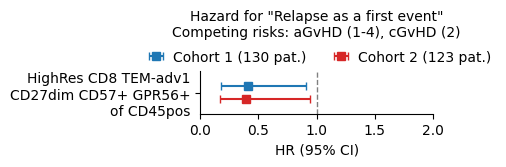

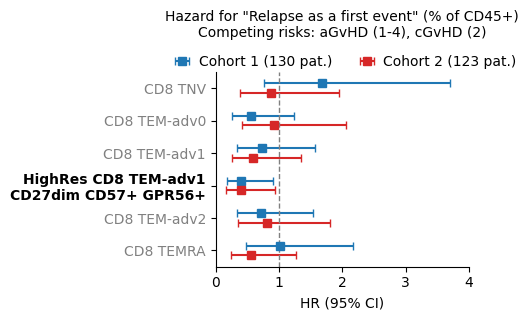

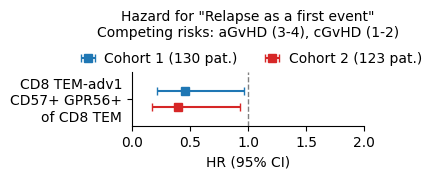

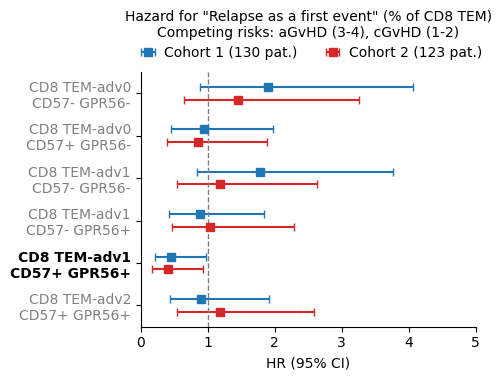

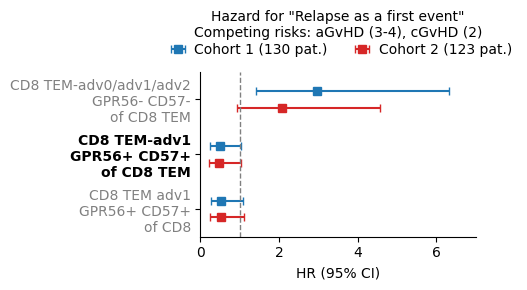

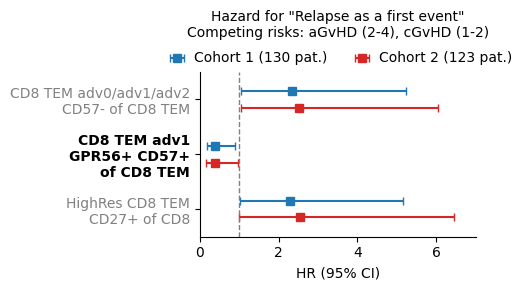

In [ ]:
for analysis_type_selected in submit_info_dict:
    main_path = submit_info_dict[analysis_type_selected]['table_path']
    replacement_dict = submit_info_dict[analysis_type_selected]['replacement_dict']

    main_table = pd.read_excel(main_path)
    main_table = HR_calculator(main_table)
    main_table = main_table[main_table['Marker'].isin(list(replacement_dict.keys()))]

    main_table['Marker'] = (main_table['Marker'].replace(replacement_dict))
    main_table['Marker'] = pd.Categorical(main_table['Marker'], categories=list(replacement_dict.values()), ordered=True)
    main_table = main_table.sort_values("Marker").reset_index(drop=True)

    # specify the path to the directory where the HR plots will be saved:
    base_dir_plot = ''
    if analysis_type_selected.endswith('extended'):
        base_dir_plot = f'{base_dir_plot}ExtendedVersions/'
    elif analysis_type_selected.endswith('main'):
        base_dir_plot = f'{base_dir_plot}MainVersions/'

    save_path = f'{base_dir_plot}{analysis_type_selected}.pdf'
    fig_width = submit_info_dict[analysis_type_selected]['width']
    fig_height = submit_info_dict[analysis_type_selected]['per_row_height']
    xlimits = submit_info_dict[analysis_type_selected]['xlimits']
    bbox_legend_pos = submit_info_dict[analysis_type_selected]['bbox_legend_pos']
    plot_title = submit_info_dict[analysis_type_selected]['plot_title']
    highlight_bold = submit_info_dict[analysis_type_selected]['highlight_bold']
    num_highlightbold = submit_info_dict[analysis_type_selected]['num_highlightbold']
    xlimits_default = submit_info_dict[analysis_type_selected]['xlimits_default']

    HR_plotter('HR',
            main_table, 
            fig_width,
            fig_height,
            bbox_legend_pos,
            xlimits_default,
            xlimits,
            plot_title,
            highlight_bold,
            num_highlightbold,
            save_fig = True,
            save_path = save_path)

<br></br>
*Figure 3: HR plots for GVHD-associated CD4 & NK parameters:*

In [ ]:
submit_info_dict = {
    '2000days_CompRisk_aGVHD234_cGVHD12_Relapse_MainRisk_aGVHDcGVHD_main_pval0.05': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            'High Resolution gdT Vd2+ Vg9+ CCR7- CD45RAmid/+ CD57+ GPR56+ of T': 'HighRes gdT Vd2+ Vg9+\nCD45RAmid/+ CD57+ GPR56+\nof T',
            'High Resolution CD3+ CD56dim CD8- CD45RA+ CD57+ GPR56+ of Lymphocytes': 'HighRes CD3+ CD56dim CD8-\nCD45RA+ CD57+ GPR56+\nof Lymphocytes',
            'High Resolution gdT Vd2+ Vg9+ CCR7- CD45RAmid CD56dim GPR56+ of T': 'HighRes gdT Vd2+ Vg9+\nCD45RAmid CD56dim GPR56+\nof T',
        },
        'width': 3,
        'per_row_height': 0.7,
        'xlimits_default': False,
        'xlimits': [0,2],
        'bbox_legend_pos': (0.5, 1.2),
        'plot_title': 'Hazard for "GvHD (aGvHD: 2-4, cGvHD: 1-2) as a first event"\nCompeting risks: relapse',
        'highlight_bold': False,
        'num_highlightbold': None
    },
    '2000days_CompRisk_aGVHD234_cGVHD12_Relapse_MainRisk_aGVHD_main_pval0.2': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            "gdT of T": "gdT of T",
            "gdT Vd2+ Vg9+ of T": "gdT Vd2+ Vg9+\nof T",
            "CD8 TEM adv0/adv1/adv2 GPR56- CD57- of CD8 TEM": "CD8 TEM adv0/adv1/adv2\nGPR56- CD57- of CD8 TEM",
            "% CXCR4+ of CD8 CCR7- CD45RAmid/+": "% CXCR4+ of\nCD8 TEM-adv2",
            "CD8 TEM adv0/adv1/adv2 GPR56- of CD8 TEM": "CD8 TEM adv0/adv1/adv2\nGPR56- of CD8 TEM",
            "CD8 TEM adv0/adv1/adv2 GPR56+ of CD8 TEM": "CD8 TEM adv0/adv1/adv2\nGPR56+ of CD8 TEM",
            "High Resolution gdT Vd1+ Naive CD27+ of gdT": "HighRes gdT Vd1+\nNaive CD27+ of gdT",
            "High Resolution gdT Vd2+ Vg9+ CCR7- CD45RAmid/+ CD57+ GPR56+ of CD45pos": "HighRes gdT Vd2+ Vg9+\nCD45RAmid/+ CD57+ GPR56+\nof CD45pos",
            "CD4-to-CD8": "CD4-to-CD8",
            "% CD29+ of CD3+ CD56dim": "% CD29+ of\nCD3+ CD56dim",
            "High Resolution CD8 CCR7- CD45RAmid CD27+ CD56dim of Lymphocytes": "HighRes CD8 TEM-adv1\nCD27+ CD56dim\nof Lymphocytes",
        },
        'width': 3,
        'per_row_height': 0.6,
        'xlimits_default': True,
        'xlimits': [0,2],
        'bbox_legend_pos': (0.5, 1.06),
        'plot_title': 'Hazard for "aGvHD (2-4) as a first event"\nCompeting risks: relapse, cGvHD (1-2)',
        'highlight_bold': False,
        'num_highlightbold': None
    },
    '2000days_CompRisk_aGVHD234_cGVHD12_Relapse_MainRisk_cGVHD1_main_pval0.2': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            "High Resolution CD3+ CD56dim CD8- CD45RA+ CD57+ GPR56+ of Lymphocytes": "HighRes CD3+ CD56+ CD8-\nCD45RA+ CD57+ GPR56+\nof Lymphocytes",
            "High Resolution gdT Vd2+ Vg9+ CCR7- CD45RAmid CD56dim GPR56+ of gdT": "HighRes gdT Vd2+ Vg9+\nCD45RAmid CD56dim GPR56+\nof gdT",
            "gdT Vd1+ of CD45pos": "gdT Vd1+\nof CD45pos",
            "High Resolution CD3+ CD56dim CD8dim CD45RA+ CD57+ GPR56+ of T": "HighRes CD3+ CD56dim CD8dim\nCD45RA+ CD57+ GPR56+\nof T",
        },
        'width': 3,
        'per_row_height': 0.7,
        'xlimits_default': True,
        'xlimits': [0,2],
        'bbox_legend_pos': (0.5, 1.16),
        'plot_title': 'Hazard for "cGvHD (1) as a first event"\nCompeting risks: relapse, aGvHD (2-4), cGvHD (2)',
        'highlight_bold': False,
        'num_highlightbold': None
    },
    '2000days_CompRisk_aGVHD234_cGVHD12_Relapse_MainRisk_cGVHD2_main_pval0.05': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            "High Resolution gdT Vd2+ Vg9+ CCR7- CD45RAmid/+ CD57+ GPR56+ of T": "HighRes gdT Vd2+ Vg9+\nCD45RAmid/+ CD57+ GPR56+\nof T",
            "High Resolution CD4 Naive CD27+ of T": "HighRes CD4 NV\nCD27+ of T",
        },
        'width': 5,
        'per_row_height': 1.2,
        'xlimits_default': True,
        'xlimits': [0,12],
        'bbox_legend_pos': (0.5, 1.35),
        'plot_title': 'Hazard for "cGvHD (2) as a first event"\nCompeting risks: relapse, aGvHD (2-4), cGvHD (1)',
        'highlight_bold': False,
        'num_highlightbold': None
    },
    '2000days_CompRisk_aGVHD234_cGVHD12_Relapse_MainRisk_cGVHD_main_pval0.05': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            "High Resolution CD4 Naive CD27+ of T": "HighRes CD4 NV\nCD27+ of T",
            "High Resolution CD8 TEM CD27+ of CD8 CCR7- CD45RA-": "HighRes CD8 TEM-adv0 CD27+\nof CD8 TEM-adv0",
            "High Resolution gdT Vd2+ Vg9+ CCR7- CD45RAmid/+ CD57+ GPR56+ of T": "HighRes gdT Vd2+ Vg9+\nCD45RAmid/+ CD57+ GPR56+\nof T",
            "CD4_Naive+CD4_TCM-to-CD4_rest": "CD4_NV+CD4_TCM\nto CD4_rest",
            "High Resolution CD4 TEM CD27dim CD29+ CD57+ GPR56+ of CD4": "HighRes CD4 TEM\nCD27dim CD29+ CD57+ GPR56+\nof CD4",
        },
        'width': 5,
        'per_row_height': 0.8,
        'xlimits_default': True,
        'xlimits': [0,12],
        'bbox_legend_pos': (0.5, 1.1),
        'plot_title': 'Hazard for "cGvHD (1-2) as a first event"\nCompeting risks: relapse, aGvHD (2-4)',
        'highlight_bold': False,
        'num_highlightbold': None
    },

    '2000days_CompRisk_aGVHD234_cGVHD2_Relapse_MainRisk_aGVHDcGVHD_main_pval0.05': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            "High Resolution gdT Vd2+ Vg9+ CCR7- CD45RAmid/+ CD57+ GPR56+ of T": "HighRes gdT Vd2+ Vg9+\nCD45RAmid/+ CD57+ GPR56+\nof T",
        },
        'width': 4,
        'per_row_height': 0.8,
        'xlimits_default': False,
        'xlimits': [0,2],
        'bbox_legend_pos': (0.5, 1.6),
        'plot_title': 'Hazard for "GvHD (aGvHD: 2-4, cGvHD: 2) as a first event"\nCompeting risks: relapse',
        'highlight_bold': False,
        'num_highlightbold': None
    },
    '2000days_CompRisk_aGVHD234_cGVHD2_Relapse_MainRisk_aGVHD_main_pval0.2': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            "gdT of T": "gdT of T",
            "CD8 TEM adv0/adv1/adv2 GPR56- CD57- of CD8 TEM": "CD8 TEM adv0/adv1/adv2\nGPR56- CD57- of CD8 TEM",
            "gdT Vd2+ Vg9+ of T": "gdT Vd2+ Vg9+\nof T",
            "CD8 TEM adv0/adv1/adv2 GPR56+ of CD8 TEM": "CD8 TEM adv0/adv1/adv2\nGPR56+ of CD8 TEM",
            "CD8 TEM adv0/adv1/adv2 GPR56- of CD8 TEM": "CD8 TEM adv0/adv1/adv2\nGPR56- of CD8 TEM",
            "% CXCR4+ of CD8 CCR7- CD45RAmid/+": "% CXCR4+\nof CD8 TEM-adv2",
            "High Resolution gdT Vd2+ Vg9+ CCR7- CD45RAmid/+ CD57+ GPR56+ of CD45pos": "HighRes gdT Vd2+ Vg9+\nCD45RAmid/+ CD57+ GPR56+\nof CD45pos",
            "High Resolution gdT Vd1+ Naive CD27+ of gdT": "HighRes gdT Vd1+ NV\nCD27+ of gdT",
            "% CD29+ of CD3+ CD56dim": "% CD29+\nof CD3+ CD56dim",
            "High Resolution CD8 CCR7- CD45RAmid CD27+ CD56dim of CD8": "HighRes CD8 TEM-adv1\nCD27+ CD56dim of CD8",
            "High Resolution CD8 CCR7- CD45RAmid CD27+ CD56dim of Lymphocytes": "HighRes CD8 TEM-adv1\nCD27+ CD56dim of Lymphocytes",
        },
        'width': 5,
        'per_row_height': 0.6,
        'xlimits_default': True,
        'xlimits': [0,2],
        'bbox_legend_pos': (0.5, 1.05),
        'plot_title': 'Hazard for "aGvHD (2-4) as a first event"\nCompeting risks: relapse, cGvHD (2)',
        'highlight_bold': False,
        'num_highlightbold': None
    },
    '2000days_CompRisk_aGVHD234_cGVHD2_Relapse_MainRisk_cGVHD_main_pval0.05': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            "High Resolution gdT Vd2+ Vg9+ CCR7- CD45RAmid/+ CD57+ GPR56+ of T": "HighRes gdT Vd2+ Vg9+\nCD45RAmid/+ CD57+ GPR56+\nof T",
        },
        'width': 4,
        'per_row_height': 0.8,
        'xlimits_default': False,
        'xlimits': [0,2],
        'bbox_legend_pos': (0.5, 1.6),
        'plot_title': 'Hazard for "cGvHD (2) as a first event"\nCompeting risks: relapse, aGvHD (2-4)',
        'highlight_bold': False,
        'num_highlightbold': None
    },

    '2000days_CompRisk_aGVHD1234_cGVHD12_Relapse_MainRisk_aGVHDcGVHD_main_pval0.05': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            "High Resolution gdT Vd2+ Vg9+ CCR7- CD45RAmid/+ CD57+ GPR56+ of T": "HighRes gdT Vd2+ Vg9+\nCD45RAmid/+ CD57+ GPR56+\nof T",
        },
        'width': 4,
        'per_row_height': 0.8,
        'xlimits_default': False,
        'xlimits': [0,2],
        'bbox_legend_pos': (0.5, 1.6),
        'plot_title': 'Hazard for "GvHD (aGvHD: 1-4, cGvHD: 1-2) as a first event"\nCompeting risks: relapse',
        'highlight_bold': False,
        'num_highlightbold': None
    },
    '2000days_CompRisk_aGVHD1234_cGVHD12_Relapse_MainRisk_aGVHD_main_pval0.2': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            "High Resolution CD8 CCR7- CD45RAmid CD27+ of CD45pos": "HighRes CD8 TEM-adv1\nCD27+ of CD45pos",
        },
        'width': 4,
        'per_row_height': 0.8,
        'xlimits_default': False,
        'xlimits': [0,2],
        'bbox_legend_pos': (0.5, 1.6),
        'plot_title': 'Hazard for "aGvHD (1-4) as a first event"\nCompeting risks: relapse, cGvHD (1-2)',
        'highlight_bold': False,
        'num_highlightbold': None
    },
    '2000days_CompRisk_aGVHD1234_cGVHD12_Relapse_MainRisk_cGVHD1_main_pval0.2': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            "gdT Vd1+ of CD45pos": "gdT Vd1+\nof CD45pos",
        },
        'width': 4,
        'per_row_height': 0.8,
        'xlimits_default': False,
        'xlimits': [0,5],
        'bbox_legend_pos': (0.5, 1.6),
        'plot_title': 'Hazard for "cGvHD (1) as a first event"\nCompeting risks: relapse, aGvHD (1-4), cGvHD (2)',
        'highlight_bold': False,
        'num_highlightbold': None
    },
    '2000days_CompRisk_aGVHD1234_cGVHD12_Relapse_MainRisk_cGVHD2_main_pval0.05': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            "High Resolution gdT Vd2+ Vg9+ CCR7- CD45RAmid/+ CD57+ GPR56+ of T": "HighRes gdT Vd2+ Vg9+\nCD45RAmid/+ CD57+ GPR56+\nof T",
            "High Resolution CD8dim TEM-adv0 CD27dim GPR56+ of CD8 CCR7- CD45RA-": "HighRes CD8dim TEM-adv0\nCD27dim GPR56+\nof CD8 TEM-adv0",
            "High Resolution CD4 Naive CD27+ of T": "HighRes CD4 NV\nCD27+ of T",
        },
        'width': 5,
        'per_row_height': 1,
        'xlimits_default': True,
        'xlimits': [0,5],
        'bbox_legend_pos': (0.5, 1.2),
        'plot_title': 'Hazard for "cGvHD (2) as a first event"\nCompeting risks: relapse, aGvHD (1-4), cGvHD (1)',
        'highlight_bold': False,
        'num_highlightbold': None
    },
    '2000days_CompRisk_aGVHD1234_cGVHD12_Relapse_MainRisk_cGVHD_main_pval0.05': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            "High Resolution CD4 TEM CD27dim CD29+ CD57+ GPR56+ of CD4": "HighRes CD4 TEM\nCD27dim CD29+ CD57+ GPR56+\nof CD4",
            "High Resolution CD4 TEM CD27dim CD29+ CD57+ of CD4": "HighRes CD4 TEM\nCD27dim CD29+ CD57+\nof CD4",
            "CD4 TEM GPR56+ of CD4": "CD4 TEM\nGPR56+ of CD4",
            "High Resolution CD4 Naive CD27+ of T": "HighRes CD4 NV\nCD27+ of T",
            "High Resolution CD8 TEM CD27+ of CD8 CCR7- CD45RA-": "HighRes CD8 TEM-adv0\nCD27+ of CD8 TEM-adv0",
            "CD4_Naive+CD4_TCM-to-CD4_rest": "CD4_NV+CD4_TCM\nto CD4_rest",
            "High Resolution gdT Vd2+ Vg9+ CCR7- CD45RAmid/+ CD57+ GPR56+ of T": "HighRes gdT Vd2+ Vg9+\nCD45RAmid/+ CD57+ GPR56+\nof T",
        },
        'width': 5,
        'per_row_height': 0.7,
        'xlimits_default': True,
        'xlimits': [0,5],
        'bbox_legend_pos': (0.5, 1.1),
        'plot_title': 'Hazard for "cGvHD (1-2) as a first event"\nCompeting risks: relapse, aGvHD (1-4)',
        'highlight_bold': False,
        'num_highlightbold': None
    },

    '2000days_CompRisk_aGVHD1234_cGVHD2_Relapse_MainRisk_aGVHDcGVHD_main_pval0.1': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            "High Resolution Double Negative T CCR7- CD45RAmid of Lymphocytes": "HighRes Double Negative T\nCCR7- CD45RAmid\nof Lymphocytes",
        },
        'width': 4,
        'per_row_height': 0.8,
        'xlimits_default': False,
        'xlimits': [0,2],
        'bbox_legend_pos': (0.5, 1.6),
        'plot_title': 'Hazard for "GvHD (aGvHD: 1-4, cGvHD: 2) as a first event"\nCompeting risks: relapse',
        'highlight_bold': False,
        'num_highlightbold': None
    },
    '2000days_CompRisk_aGVHD1234_cGVHD2_Relapse_MainRisk_aGVHD_main_pval0.2': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            "High Resolution CD8 CCR7- CD45RAmid CD27+ of CD45pos": "HighRes CD8 TEM-adv1\nCD27+ of CD45pos",
        },
        'width': 4,
        'per_row_height': 0.8,
        'xlimits_default': False,
        'xlimits': [0,2],
        'bbox_legend_pos': (0.5, 1.6),
        'plot_title': 'Hazard for "aGvHD (1-4) as a first event"\nCompeting risks: relapse, cGvHD (2)',
        'highlight_bold': False,
        'num_highlightbold': None
    },
    '2000days_CompRisk_aGVHD1234_cGVHD2_Relapse_MainRisk_cGVHD_main_pval0.05': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            "High Resolution CD8dim TEM-adv0 CD27dim GPR56+ of CD8 CCR7- CD45RA-": "HighRes CD8dim TEM-adv0\nCD27dim GPR56+\nof CD8 TEM-adv0",
            "High Resolution CD4 Naive CD27+ of T": "HighRes CD4 NV\nCD27+ of T",
            "High Resolution gdT Vd2+ Vg9+ CCR7- CD45RAmid/+ CD57+ GPR56+ of T": "HighRes gdT Vd2+ Vg9+\nCD45RAmid/+ CD57+ GPR56+\nof T",
        },
        'width': 5.5,
        'per_row_height': 1,
        'xlimits_default': True,
        'xlimits': [0,2],
        'bbox_legend_pos': (0.5, 1.2),
        'plot_title': 'Hazard for "cGvHD (2) as a first event"\nCompeting risks: relapse, aGvHD (1-4)',
        'highlight_bold': False,
        'num_highlightbold': None
    },

    '2000days_CompRisk_aGVHD34_cGVHD12_Relapse_MainRisk_aGVHDcGVHD_main_pval0.05': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            "High Resolution CD3+ CD56dim CD8- CD45RA+ CD57+ GPR56+ of Lymphocytes": "HighRes CD3+ CD56dim CD8-\nCD45RA+ CD57+ GPR56+\nof Lymphocytes",
            "High Resolution CD56dim NK CD45RA+ CD57+ GPR56+ of Lymphocytes": "HighRes CD56dim NK\nCD45RA+ CD57+ GPR56+\nof Lymphocytes",
            "CD56dim NK CD57+ GPR56+ of Lymphocytes": "CD56dim NK CD57+ GPR56+\nof Lymphocytes",
            "High Resolution CD3+ CD56dim CD8- CD45RA+ CD57+ GPR56+ of T": "HighRes CD3+ CD56dim CD8-\nCD45RA+ CD57+ GPR56+\nof T",
            "CD4 TEM of CD4": "CD4 TEM of CD4",
            "CD4_Naive+CD4_TCM-to-CD4_rest": "CD4_NV+CD4_TCM\nto CD4_rest",
            "High Resolution CD4 Naive CD27+ of T": "HighRes CD4 NV\nCD27+ of T",
            "High Resolution Double Negative T CCR7- CD45RA+ CD57+ GPR56+ of Lymphocytes": "HighRes Double Negative T\nCCR7- CD45RA+ CD57+ GPR56+\nof Lymphocytes",
            "High Resolution CD4 TEM CD27dim CD29+ CD57+ GPR56+ of CD4": "HighRes CD4 TEM\nCD27dim CD29+ CD57+ GPR56+\nof CD4",
            "High Resolution CD4 TEM CD27dim CD29+ CD57+ of CD4": "HighRes CD4 TEM\nCD27dim CD29+ CD57+\nof CD4",
        },
        'width': 5,
        'per_row_height': 0.65,
        'xlimits_default': True,
        'xlimits': [0,2],
        'bbox_legend_pos': (0.5, 1.07),
        'plot_title': 'Hazard for "GvHD (aGvHD: 3-4, cGvHD: 1-2) as a first event"\nCompeting risks: relapse',
        'highlight_bold': False,
        'num_highlightbold': None
    },
    '2000days_CompRisk_aGVHD34_cGVHD12_Relapse_MainRisk_aGVHD_main_pval0.2': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            "CD56dim NK CD57+ GPR56+ of Lymphocytes": "CD56dim NK CD57+ GPR56+\nof Lymphocytes",
            "High Resolution CD3+ CD56dim CD8- CD45RA+ CD57+ GPR56+ of T": "HighRes CD3+ CD56dim CD8-\nCD45RA+ CD57+ GPR56+\nof T",
            "High Resolution CD56dim NK CD45RA+ CD57+ GPR56+ of Lymphocytes": "HighRes CD56dim NK\nCD45RA+ CD57+ GPR56+\nof Lymphocytes",
            "% CXCR4+ of CD3+ CD56dim": "% CXCR4+\nof CD3+ CD56dim",
            "High Resolution CD8 TEMRA CD27dim GPR56+ of CD8 CCR7- CD45RA+": "HighRes CD8 TEMRA\nCD27dim GPR56+\nof CD8 TEMRA",
            # "% CD29+ of CD3+ CD56dim": "% CD29+\nof CD3+ CD56dim",
            "High Resolution CD8 CCR7- CD45RAmid CD57+ GPR56+ of CD8": "HighRes CD8 TEM-adv1\nCD57+ GPR56+ of CD8",
        },
        'width': 5.5,
        'per_row_height': 0.7,
        'xlimits_default': True,
        'xlimits': [0,2],
        'bbox_legend_pos': (0.5, 1.12),
        'plot_title': 'Hazard for "aGvHD (3-4) as a first event"\nCompeting risks: relapse, cGvHD (1-2)',
        'highlight_bold': False,
        'num_highlightbold': None
    },
    '2000days_CompRisk_aGVHD34_cGVHD12_Relapse_MainRisk_cGVHD1_main_pval0.2': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            "High Resolution CD3+ CD56dim CD8dim CD45RA+ CD57+ GPR56+ of T": "HighRes CD3+ CD56dim CD8dim\nCD45RA+ CD57+ GPR56+\nof T",
            "High Resolution CD56dim NK CD45RA+ CD57+ GPR56+ of Lymphocytes": "HighRes CD56dim NK\nCD45RA+ CD57+ GPR56+\nof Lymphocytes",
            "High Resolution CD3+ CD56dim CD8dim CD45RA+ CD57+ GPR56+ of Lymphocytes": "HighRes CD3+ CD56dim CD8dim\nCD45RA+ CD57+ GPR56+\nof Lymphocytes",
            "High Resolution Double Negative T CCR7- CD45RA+ CD57+ GPR56+ of Lymphocytes": "HighRes Double Negative T\nCCR7- CD45RA+ CD57+ GPR56+\nof Lymphocytes",
            "High Resolution CD3+ CD56dim CD8- CD45RA+ CD57+ GPR56+ of Lymphocytes": "HighRes CD3+ CD56dim CD8-\nCD45RA+ CD57+ GPR56+\nof Lymphocytes",
            "High Resolution Double Negative T CCR7- CD45RAmid of Double Negative T": "HighRes Double Negative T\nCCR7- CD45RAmid\nof Double Negative T",
            "High Resolution Double Negative T CCR7- CD45RA+ CD57+ GPR56+ of Double Negative T": "HighRes Double Negative T\nCCR7- CD45RA+ CD57+ GPR56+\nof Double Negative T",
            "High Resolution gdT Vd2+ Vg9+ CCR7- CD45RAmid CD56dim GPR56+ of gdT": "HighRes gdT Vd2+ Vg9+\nCD45RAmid CD56dim GPR56+\nof gdT",
            "gdT Vd1+ of CD45pos": "gdT Vd1+\nof CD45pos",
        },
        'width': 5.5,
        'per_row_height': 0.7,
        'xlimits_default': True,
        'xlimits': [0,2],
        'bbox_legend_pos': (0.5, 1.08),
        'plot_title': 'Hazard for "cGvHD (1) as a first event"\nCompeting risks: relapse, aGvHD (3-4), cGvHD (2)',
        'highlight_bold': False,
        'num_highlightbold': None
    },
    '2000days_CompRisk_aGVHD34_cGVHD12_Relapse_MainRisk_cGVHD2_main_pval0.05': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            "CD8 CCR7- CD45RAmid of CD8": "CD8 TEM-adv1\nof CD8",
            "High Resolution CD4 Naive CD27+ of CD45pos": "HighRes CD4 NV\nCD27+ of CD45pos",
            "High Resolution CD4 TEM CD27- CD29+ of CD4": "HighRes CD4 TEM\nCD27- CD29+ of CD4",
        },
        'width': 5,
        'per_row_height': 0.85,
        'xlimits_default': True,
        'xlimits': [0,2],
        'bbox_legend_pos': (0.5, 1.3),
        'plot_title': 'Hazard for "cGvHD (2) as a first event"\nCompeting risks: relapse, aGvHD (3-4), cGvHD (1)',
        'highlight_bold': False,
        'num_highlightbold': None
    },
    '2000days_CompRisk_aGVHD34_cGVHD12_Relapse_MainRisk_cGVHD_main_pval0.05': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            "High Resolution CD4 TEM CD27dim CD29+ CD57+ GPR56+ of CD4": "HighRes CD4 TEM\nCD27dim CD29+ CD57+ GPR56+\nof CD4",
            "High Resolution CD4 TEM CD27dim CD29+ CD57+ of CD4": "HighRes CD4 TEM\nCD27dim CD29+ CD57+\nof CD4",
            "CD4_Naive+CD4_TCM-to-CD4_rest": "CD4_NV+CD4_TCM\nto CD4_rest",
            "High Resolution CD8 TEM CD27+ of CD8 CCR7- CD45RA-": "HighRes CD8 TEM-adv0\nCD27+ of CD8 TEM-adv0",
            "High Resolution CD8 TEM-adv1 CD27dim CD57+ GPR56+ of CD8": "HighRes CD8 TEM-adv1\nCD27dim CD57+ GPR56+\nof CD8",
            "High Resolution CD4 TEM CD27dim CD29+ CD57+ GPR56+ of CD4 TEM": "HighRes CD4 TEM\nCD27dim CD29+ CD57+ GPR56+\nof CD4 TEM",
            "High Resolution CD4 Naive CD27+ of T": "HighRes CD4 NV\nCD27+ of T",
        },
        'width': 5,
        'per_row_height': 0.75,
        'xlimits_default': True,
        'xlimits': [0,2],
        'bbox_legend_pos': (0.5, 1.09),
        'plot_title': 'Hazard for "cGvHD (1-2) as a first event"\nCompeting risks: relapse, aGvHD (3-4)',
        'highlight_bold': False,
        'num_highlightbold': None
    },

    '2000days_CompRisk_aGVHD34_cGVHD2_Relapse_MainRisk_aGVHDcGVHD_main_pval0.05': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            "High Resolution CD4 Naive CD27+ of T": "HighRes CD4 NV\nCD27+ of T",
            "High Resolution CD4 TEM CD27- CD29+ of CD4": "HighRes CD4 TEM\nCD27- CD29+ of CD4",
        },
        'width': 5,
        'per_row_height': 1.1,
        'xlimits_default': True,
        'xlimits': [0,2],
        'bbox_legend_pos': (0.5, 1.4),
        'plot_title': 'Hazard for "GvHD (aGvHD: 3-4, cGvHD: 2) as a first event"\nCompeting risks: relapse',
        'highlight_bold': False,
        'num_highlightbold': None
    },
    '2000days_CompRisk_aGVHD34_cGVHD2_Relapse_MainRisk_aGVHD_main_pval0.2': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            "CD56dim NK CD57+ GPR56+ of Lymphocytes": "CD56dim NK\nCD57+ GPR56+\nof Lymphocytes",
            "High Resolution CD3+ CD56dim CD8- CD45RA+ CD57+ GPR56+ of T": "HighRes CD3+ CD56dim CD8-\nCD45RA+ CD57+ GPR56+\nof T",
            "High Resolution CD56dim NK CD45RA+ CD57+ GPR56+ of Lymphocytes": "HighRes CD56dim NK\nCD45RA+ CD57+ GPR56+\nof Lymphocytes",
            "High Resolution CD8 TEMRA CD27dim GPR56+ of CD8 CCR7- CD45RA+": "HighRes CD8 TEMRA\nCD27dim GPR56+\nof CD8 TEMRA",
            # "% CD29+ of CD3+ CD56dim": "% CD29+\nof CD3+ CD56dim",
            "High Resolution CD56dim NK CD45RA+ CD57+ GPR56+ of CD45pos": "HighRes CD56dim NK\nCD45RA+ CD57+ GPR56+\nof CD45pos",
            "High Resolution CD8 CCR7- CD45RAmid CD57+ GPR56+ of CD8 TEM": "HighRes CD8 TEM-adv1\nCD57+ GPR56+\nof CD8 TEM",
        },
        'width': 5,
        'per_row_height': 0.8,
        'xlimits_default': True,
        'xlimits': [0,2],
        'bbox_legend_pos': (0.5, 1.1),
        'plot_title': 'Hazard for "aGvHD (3-4) as a first event"\nCompeting risks: relapse, cGvHD (2)',
        'highlight_bold': False,
        'num_highlightbold': None
    },
    '2000days_CompRisk_aGVHD34_cGVHD2_Relapse_MainRisk_cGVHD_main_pval0.05': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            "High Resolution CD4 Naive CD27+ of CD45pos": "HighRes CD4 NV\nCD27+ of CD45pos",
            "CD8 CCR7- CD45RAmid of CD8": "CD8 TEM-adv1\nof CD8",
        },
        'width': 5,
        'per_row_height': 1.1,
        'xlimits_default': True,
        'xlimits': [0,2],
        'bbox_legend_pos': (0.5, 1.4),
        'plot_title': 'Hazard for "cGvHD (2) as a first event"\nCompeting risks: relapse, aGvHD (3-4)',
        'highlight_bold': False,
        'num_highlightbold': None
    },
}

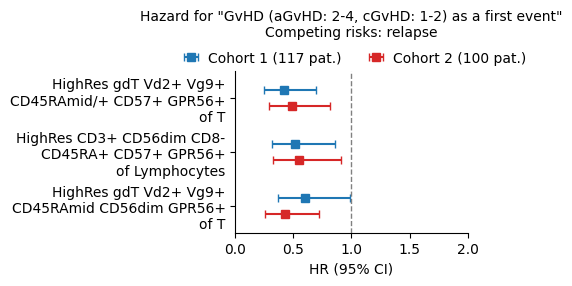

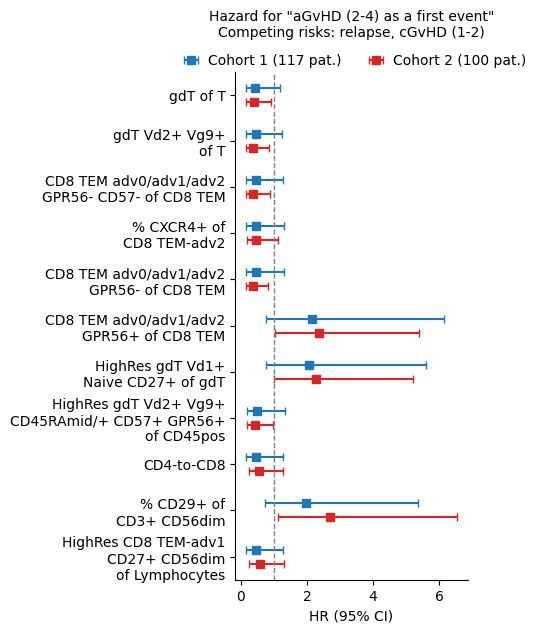

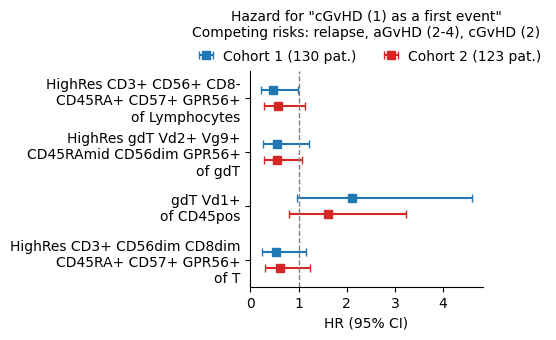

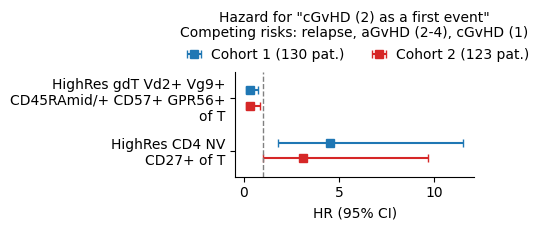

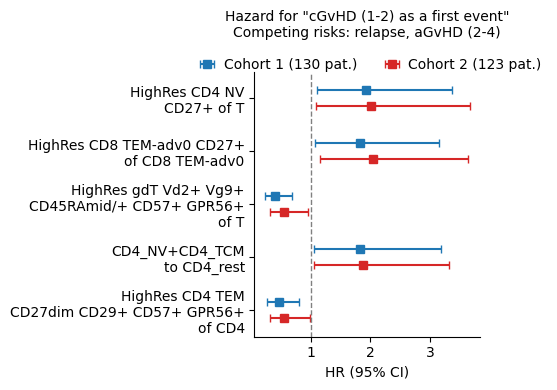

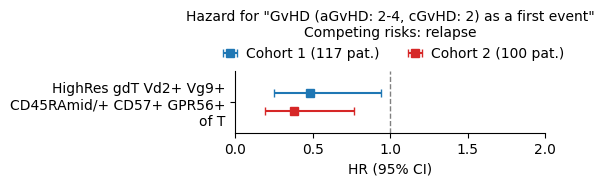

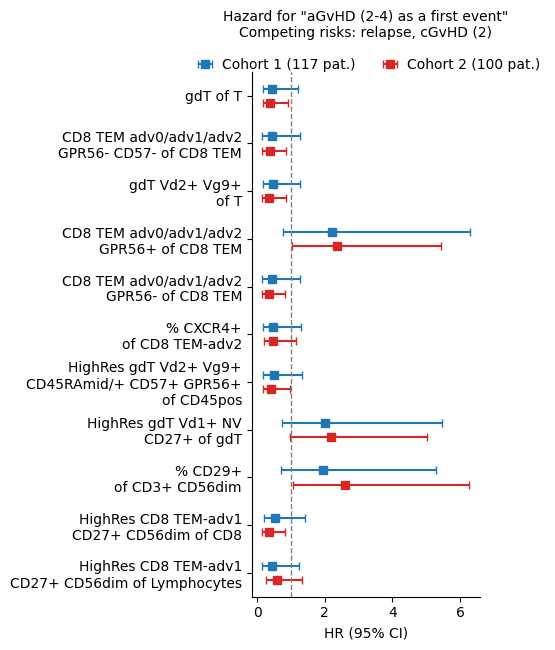

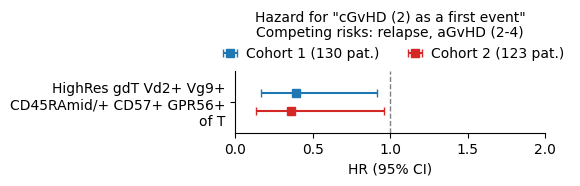

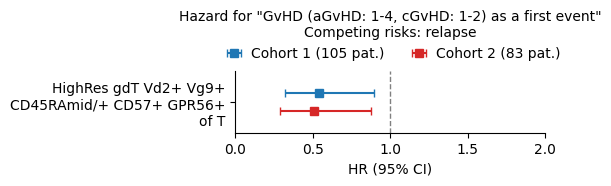

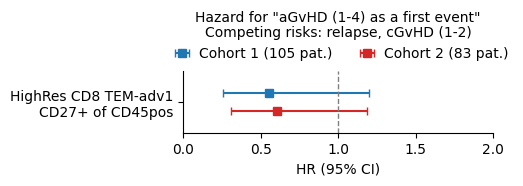

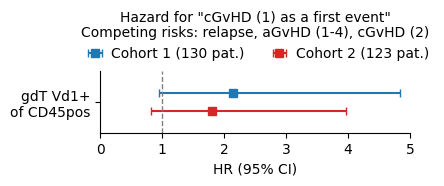

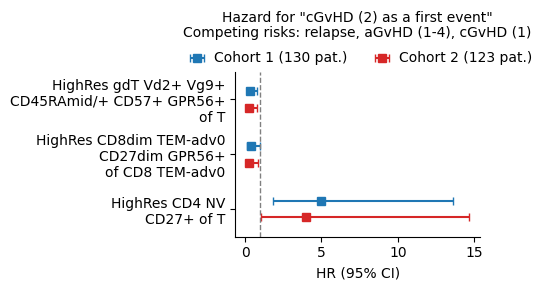

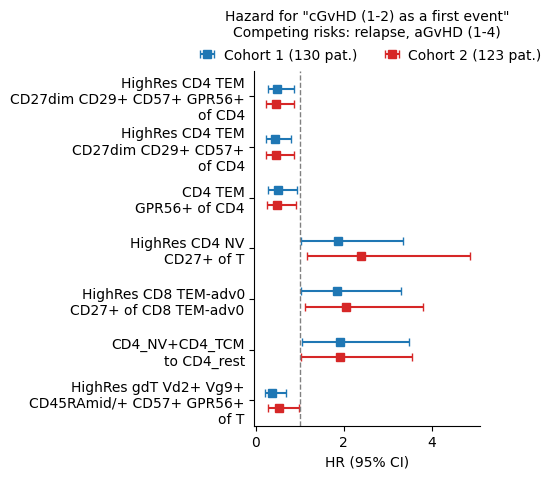

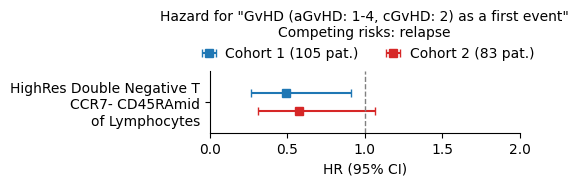

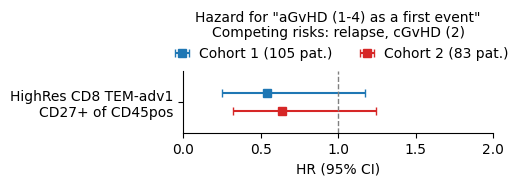

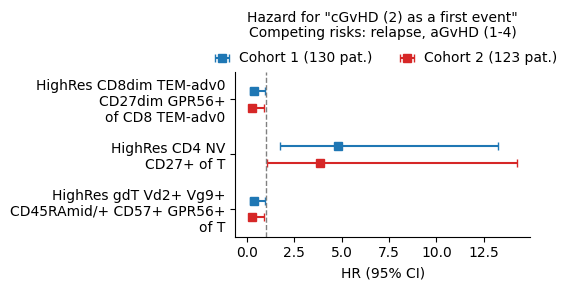

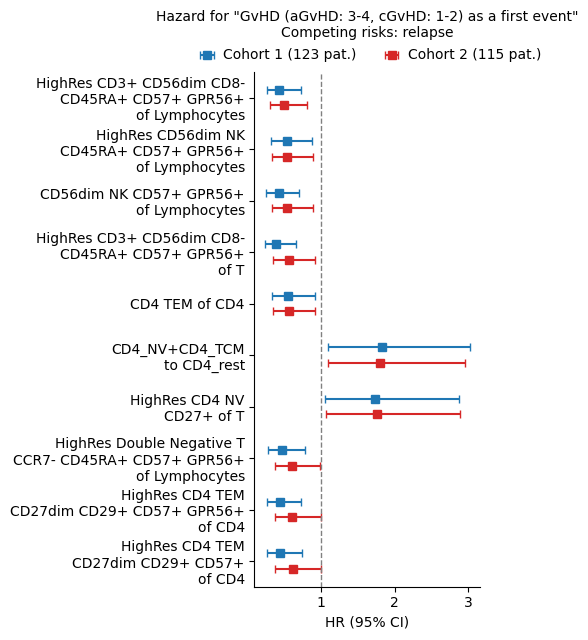

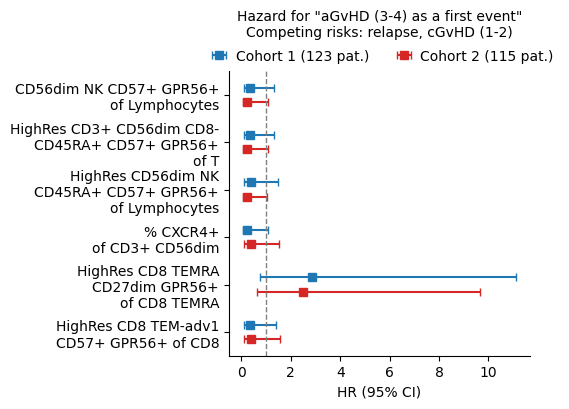

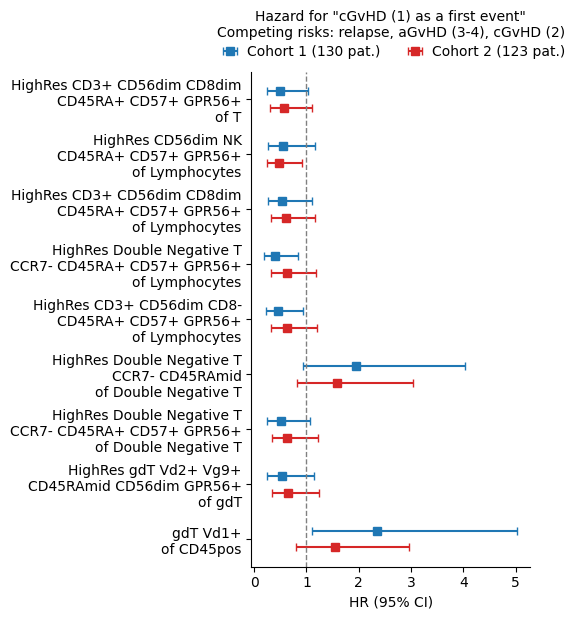

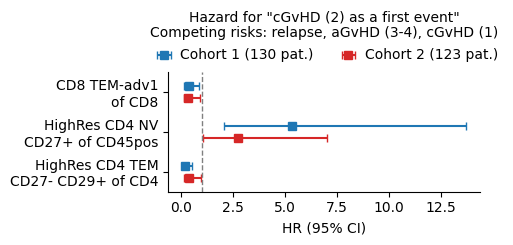

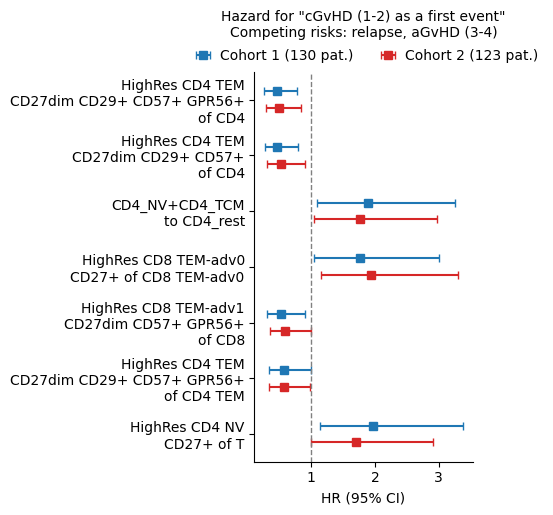

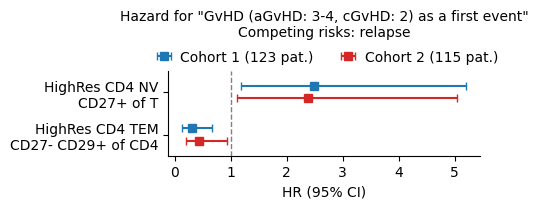

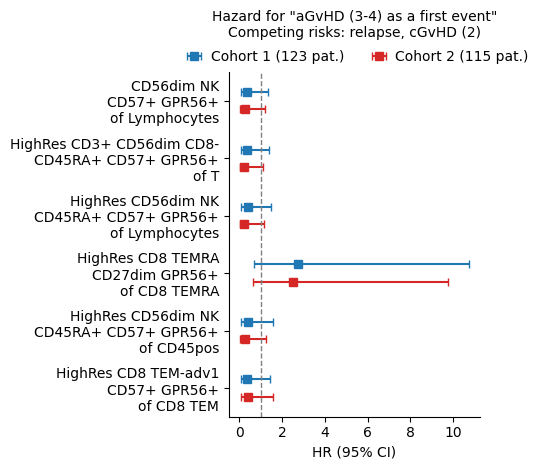

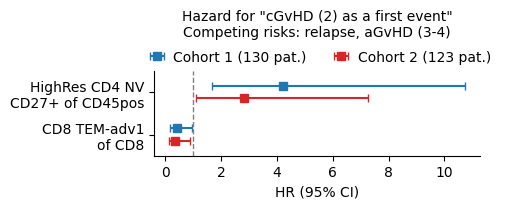

In [ ]:
for analysis_type_selected in submit_info_dict:
    main_path = submit_info_dict[analysis_type_selected]['table_path']
    replacement_dict = submit_info_dict[analysis_type_selected]['replacement_dict']

    main_table = pd.read_excel(main_path)
    main_table = HR_calculator(main_table)
    main_table = main_table[main_table['Marker'].isin(list(replacement_dict.keys()))]

    main_table['Marker'] = (main_table['Marker'].replace(replacement_dict))
    main_table['Marker'] = pd.Categorical(main_table['Marker'], categories=list(replacement_dict.values()), ordered=True)
    main_table = main_table.sort_values("Marker").reset_index(drop=True)

    # specify the path to the directory where the HR plots will be saved:
    base_dir_plot = ''
    save_path = f'{base_dir_plot}{analysis_type_selected}.pdf'
    fig_width = submit_info_dict[analysis_type_selected]['width']
    fig_height = submit_info_dict[analysis_type_selected]['per_row_height']
    xlimits = submit_info_dict[analysis_type_selected]['xlimits']
    bbox_legend_pos = submit_info_dict[analysis_type_selected]['bbox_legend_pos']
    plot_title = submit_info_dict[analysis_type_selected]['plot_title']
    highlight_bold = submit_info_dict[analysis_type_selected]['highlight_bold']
    num_highlightbold = submit_info_dict[analysis_type_selected]['num_highlightbold']
    xlimits_default = submit_info_dict[analysis_type_selected]['xlimits_default']

    HR_plotter('HR',
            main_table, 
            fig_width,
            fig_height,
            bbox_legend_pos,
            xlimits_default,
            xlimits,
            plot_title,
            highlight_bold,
            num_highlightbold,
            save_fig = True,
            save_path = save_path)

<br></br>
*Figure 3: HR plots for GRFS-specific surival analysis results:*

In [ ]:
submit_info_dict = {
    '2000days_GRFS_aGVHD234_cGVHD12_Relapse_Death_MainRisk_GRFS_main_pval0.05': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',        
        'replacement_dict': {
            "High Resolution gdT Vd2+ Vg9+ CCR7- CD45RAmid/+ CD57+ GPR56+ of T": "HighRes gdT Vd2+ Vg9+\nCD45RAmid/+ CD57+ GPR56+\nof T",
            "Double Negative T of Lymphocytes": "Double Negative T\nof Lymphocytes",
        },
        'width': 3,
        'per_row_height': 0.7,
        'xlimits_default': False,
        'xlimits': [0,2],
        'bbox_legend_pos': (0.5, 1.35),
        'plot_title': 'Hazard of GRFS\nRelapse, aGvHD (2-4), cGvHD (1-2)',
        'highlight_bold': False,
        'num_highlightbold': None
    },
    '2000days_GRFS_aGVHD234_cGVHD2_Relapse_Death_MainRisk_GRFS_main_pval0.05': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            "High Resolution Double Negative T CCR7- CD45RAmid of Lymphocytes": "HighRes Double Negative T\nCCR7- CD45RAmid\nof Lymphocytes",
        },
        'width': 3,
        'per_row_height': 0.7,
        'xlimits_default': False,
        'xlimits': [0,2],
        'bbox_legend_pos': (0.5, 1.6),
        'plot_title': 'Hazard of GRFS\nRelapse, aGvHD (2-4), cGvHD (2)',
        'highlight_bold': False,
        'num_highlightbold': None
    },
    '2000days_GRFS_aGVHD34_cGVHD12_Relapse_Death_MainRisk_GRFS_main_pval0.05': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            "High Resolution Double Negative T CCR7- CD45RA+ CD57+ GPR56+ of Lymphocytes": "HighRes Double Negative T\nCCR7- CD45RA+ CD57+ GPR56+\nof Lymphocytes",
        },
        'width': 3,
        'per_row_height': 0.7,
        'xlimits_default': False,
        'xlimits': [0,2],
        'bbox_legend_pos': (0.5, 1.65),
        'plot_title': 'Hazard of GRFS\nRelapse, aGvHD (3-4), cGvHD (1-2)',
        'highlight_bold': False,
        'num_highlightbold': None
    },
    '2000days_GRFS_aGVHD34_cGVHD2_Relapse_Death_MainRisk_GRFS_main_pval0.05': {
        # path to the excel table with cause-specific hazard model results
        'table_path': '',
        'replacement_dict': {
            "CD8 TEM adv1 GPR56+ CD57+ of T": "CD8 TEM adv1\nGPR56+ CD57+\nof T",
            "High Resolution CD8 TEMRA CD27dim GPR56+ of CD8 CCR7- CD45RA+": "HighRes CD8 TEMRA\nCD27dim GPR56+\nof CD8 TEMRA",
            "CD4 CCR7mid CD45RA- of T": "CD4 TCM\nof T",
        },
        'width': 4,
        'per_row_height': 1,
        'xlimits_default': True,
        'xlimits': [0,2],
        'bbox_legend_pos': (0.5, 1.2),
        'plot_title': 'Hazard of GRFS\nRelapse, aGvHD (3-4), cGvHD (2)',
        'highlight_bold': False,
        'num_highlightbold': None
    },
}

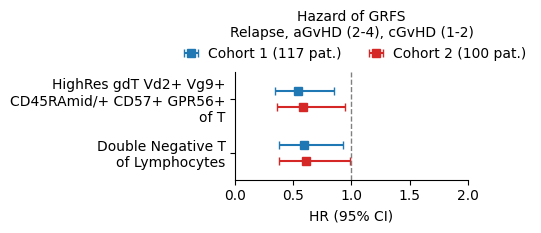

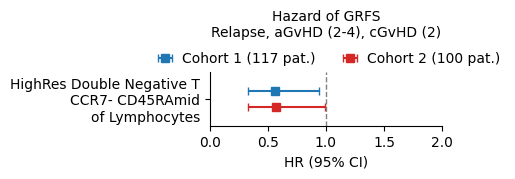

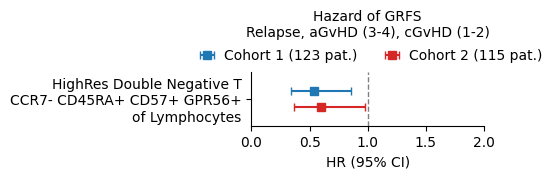

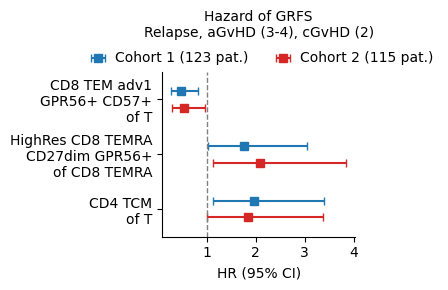

In [ ]:
for analysis_type_selected in submit_info_dict:
    main_path = submit_info_dict[analysis_type_selected]['table_path']
    replacement_dict = submit_info_dict[analysis_type_selected]['replacement_dict']

    main_table = pd.read_excel(main_path)
    main_table = HR_calculator(main_table)
    main_table = main_table[main_table['Marker'].isin(list(replacement_dict.keys()))]

    main_table['Marker'] = (main_table['Marker'].replace(replacement_dict))
    main_table['Marker'] = pd.Categorical(main_table['Marker'], categories=list(replacement_dict.values()), ordered=True)
    main_table = main_table.sort_values("Marker").reset_index(drop=True)

    # specify the path to the directory where the HR plots will be saved:
    base_dir_plot = ''
    save_path = f'{base_dir_plot}{analysis_type_selected}.pdf'
    fig_width = submit_info_dict[analysis_type_selected]['width']
    fig_height = submit_info_dict[analysis_type_selected]['per_row_height']
    xlimits = submit_info_dict[analysis_type_selected]['xlimits']
    bbox_legend_pos = submit_info_dict[analysis_type_selected]['bbox_legend_pos']
    plot_title = submit_info_dict[analysis_type_selected]['plot_title']
    highlight_bold = submit_info_dict[analysis_type_selected]['highlight_bold']
    num_highlightbold = submit_info_dict[analysis_type_selected]['num_highlightbold']
    xlimits_default = submit_info_dict[analysis_type_selected]['xlimits_default']

    HR_plotter('HR',
            main_table, 
            fig_width,
            fig_height,
            bbox_legend_pos,
            xlimits_default,
            xlimits,
            plot_title,
            highlight_bold,
            num_highlightbold,
            save_fig = True,
            save_path = save_path)